# Paper-Prophet — the teardown 🧥🔬
### An ARIMA(1,0,1)+GARCH(1,1) stack, ported faithfully and decomposed on the SPY

Same seven beats as `01_for_the_curious`, at depth: the HAC directional test, the Sharpe decomposition (forecast vs sizing), the alpha-vs-managed-beta regression, the cost sweep, and the in-sample-vs-walk-forward inflation control. Runs a ~300-day slice; the **full-tape headline** is in [`docs/results.md`](../docs/results.md) via `examples/verify.py`.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))            # study root (paper_prophet/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))       # repo root, for quantlab
os.environ.setdefault("OVERNIGHT_CACHE", os.path.abspath("../../../_cache"))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from paper_prophet import data, decompose
from paper_prophet.stack import generate_signals

# Small & fast: grade ~300 walk-forward days on the most recent SPY. The full-tape headline
# (~8,000 days) is in ../docs/results.md via examples/verify.py.
prices = data.load_spy()["Close"]
rets = data.log_returns(prices)
SLICE = rets.iloc[-(252 + 300):]          # 252-day warmup + ~300 graded days
wf = generate_signals(SLICE, lookback=252, max_steps=300)
print(f"graded {len(wf.frame)} walk-forward days, ending {wf.frame.index[-1].date()}")


graded 300 walk-forward days, ending 2026-06-01


## 1 · The Claim, as a hypothesis

H₁ (the part worth testing): the ARIMA sign carries realized directional edge, ``E[sign(f̂)·r] > 0`` with HAC *t* > 2, **and** the walk-forward Sharpe materially exceeds the *same GARCH sizing on a constant-long signal*. The sharp null is the weak-EMH random-walk-in-returns: daily index returns have negligible, non-tradable serial dependence (Fama 1970), so ``sign(f̂)`` ≈ a coin and the Sharpe is the vol-targeting term (Moreira–Muir 2017).

## 2 · So What? — the stakes are alpha vs managed beta

Vol-targeting lifts the Sharpe of *any* long-biased signal because realized vol is persistent and inversely related to forward returns. So a high stack-Sharpe is fully consistent with **zero** forecasting skill. The decisive quantity is the *increment* the ARIMA sign adds over constant-long-with-the-same-sizing, net of the turnover it induces.

## 3 · How We'd Know — pre-registered falsification

Signal `NONE` if the directional HAC *t* < 2. Tradability `MIRAGE` if the stack's Sharpe is not materially above the vol-targeting control and/or the ARIMA increment goes ≤ 0 net of costs. 'Win every trade' `BUSTED` if the win rate is a coin flip. First the GARCH sizing itself — it is genuinely informative about volatility, which is why it works:

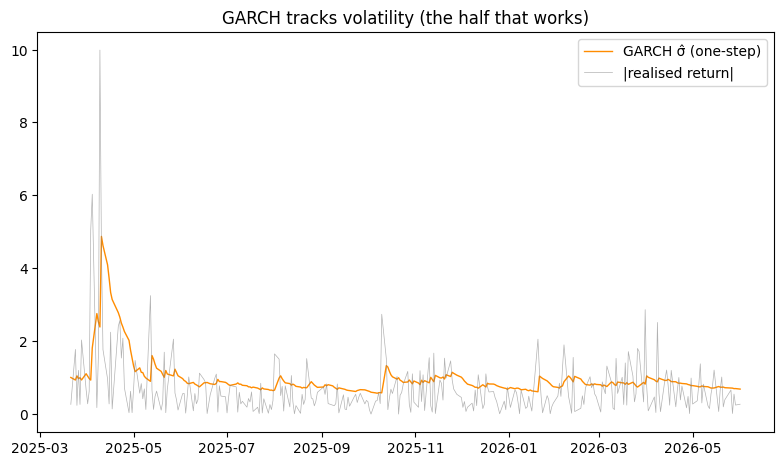

In [2]:
f = wf.frame
fig, ax = plt.subplots()
ax.plot(f.index, f['vol'], lw=1.0, color='darkorange', label='GARCH σ̂ (one-step)')
ax.plot(f.index, f['ret'].abs(), lw=0.5, color='grey', alpha=0.6, label='|realised return|')
ax.set_title('GARCH tracks volatility (the half that works)'); ax.legend(); plt.show()

## 4 · The Teardown

**(a) The direction is a coin flip.** The per-day bet ``sign(f̂)·r``, HAC-tested, is indistinguishable from zero; the hit-rate sits on 50%.

In [3]:
decompose.directional_edge(wf)

{'hit_rate': 0.51,
 'n_graded': 300,
 'dir_edge_bps_per_day': -4.007254597668296,
 'dir_edge_hac_t': -0.5443913460393288,
 'active_frac': 1.0}

**(b) The Sharpe is the sizing.** Constant-long with the *same* GARCH σ̂ reproduces most of the stack's Sharpe; the ARIMA increment is small and its bootstrap CI brackets zero.

In [4]:
sd = decompose.sharpe_decomposition(wf)
{k: (round(v,3) if isinstance(v,float) else v) for k,v in sd.items()}

{'sharpe_stack': -0.197,
 'sharpe_voltgt': 1.57,
 'sharpe_flat_forecast': -0.558,
 'sharpe_buyhold': 1.366,
 'voltgt_reproduces_frac': -7.96,
 'arima_increment_sharpe': -1.767,
 'arima_increment_ci': (-3.5029455301076204, -0.03538577342274695),
 'arima_increment_frac_negative': 0.98}

**(c) What the model 'found' is managed beta.** Regress the stack on plain SPY, then on the vol-managed-SPY factor (the constant-long×size leg). Against the managed factor the alpha collapses — the stack *is* that factor.

In [5]:
decompose.alpha_vs_beta(wf)

{'beta_market': 0.2622770016687505,
 'alpha_vs_market_pct_day': -0.036592739337774245,
 'r2_market': 0.11533645179220486,
 'beta_voltgt': 0.489365029952085,
 'alpha_vs_voltgt_pct_day': -0.05323218809354408,
 'r2_voltgt': 0.23718684708528992}

**(d) Costs eat the increment.** The forecast's sign-flips create turnover the constant-long control doesn't pay. The net ARIMA increment falls as the spread rises.

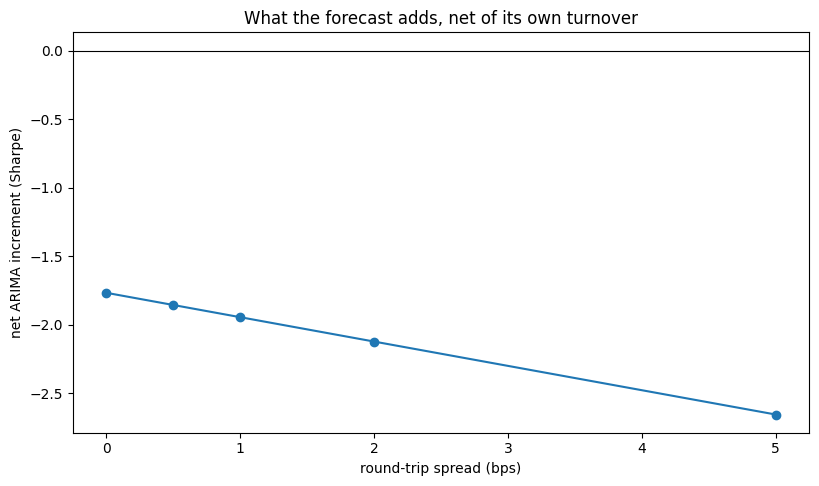

,sharpe_stack_net,sharpe_voltgt_net,arima_increment_net,stack_turnover_ann
spread_bps,,,,
0.0000,-0.1973,1.5702,-1.7675,253.1471
0.5000,-0.2880,1.5684,-1.8564,253.1471
1.0000,-0.3788,1.5665,-1.9453,253.1471
2.0000,-0.5603,1.5628,-2.1231,253.1471
5.0000,-1.1036,1.5518,-2.6553,253.1471


In [6]:
cs = decompose.cost_sweep(wf)
ax = cs['arima_increment_net'].plot(marker='o')
ax.axhline(0, color='k', lw=0.8); ax.set_xlabel('round-trip spread (bps)')
ax.set_ylabel('net ARIMA increment (Sharpe)')
ax.set_title('What the forecast adds, net of its own turnover'); plt.show()
cs.round(4)

## 5 · The Verdict

Headline (full 8,091-day tape, results.md): **Signal NONE** (hit-rate 51.98%, HAC *t* = +0.85); **Tradability MIRAGE** (vol-targeting +0.53 vs stack +0.17; ARIMA increment −0.35, 95% of bootstraps negative; alpha vs managed beta +0.0006%/day ≈ 0); **'Win every trade' BUSTED** (win rate 51.98%).

## 6 · Could You Trade It? — the in-sample mirage lives in short samples

The author rightly warns that fitting on the full series and grading in-sample is 'a curve fit with a label'. Here is the subtle part. On this **short** slice the mistake manufactures a real mirage (in-sample hit-rate well above the walk-forward one); on the **full 33-year tape** it washes out to ≈ 0 (see [`docs/results.md`](../docs/results.md)). That is the warning made concrete: a 5-year backtest — exactly the window the thread's code uses — is precisely where in-sample fitting invents an edge that does not survive out of sample. The honest, large-sample number is the one with no edge at all.

In [7]:
decompose.in_sample_inflation(SLICE, wf)   # +pp here on the short slice; ~0 on the full tape

{'hit_rate_in_sample': 0.5615942028985508,
 'hit_rate_walk_forward': 0.51,
 'inflation_pp': 5.159420289855077}

## 7 · Going Further

- The **same stack on other instruments** (commodities, FX) where the leverage effect — and thus the vol-targeting tailwind — is weaker or inverted: the 'edge' should travel with the *sizing*, not the forecast.
- **AIC-selected (p,d,q)** to check that more parameters don't rescue the direction (they fit in-sample noise; the walk-forward hit-rate stays ~50%).
- **GARCH vs Markov disagreement** — run this stack and [Study 10](../../10-markov-mint/)'s regime model on the same tape and answer the thread's own closing question.